In [33]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library("ggExtra")
library("circlize")
source('./plot_data.R')
theme_set(
    theme_classic(base_size = 12)
)

circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




## Figure 2C

In [75]:
de_df<- read.table(file = '../data/7_mature_rna_DE_results.tsv', header = T, sep = '\t', row.names = 1)

In [76]:
mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
mcolors<- c(mcolors, "grey")
names(mcolors) <- c('canonical', 'downstream', 'antisense', 'Not sig')

de_df$type = as.character(de_df$feature_id)
de_df[de_df$labels == 'Not sig', 'type'] = 'Not sig'
de_df$type<- factor(de_df$type, levels = c('canonical', 'downstream', 'antisense', 'Not sig'))
de_df[de_df$padj<10e-15, 'padj'] = 10e-15

Warning message:
“Removed 7965 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 7965 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


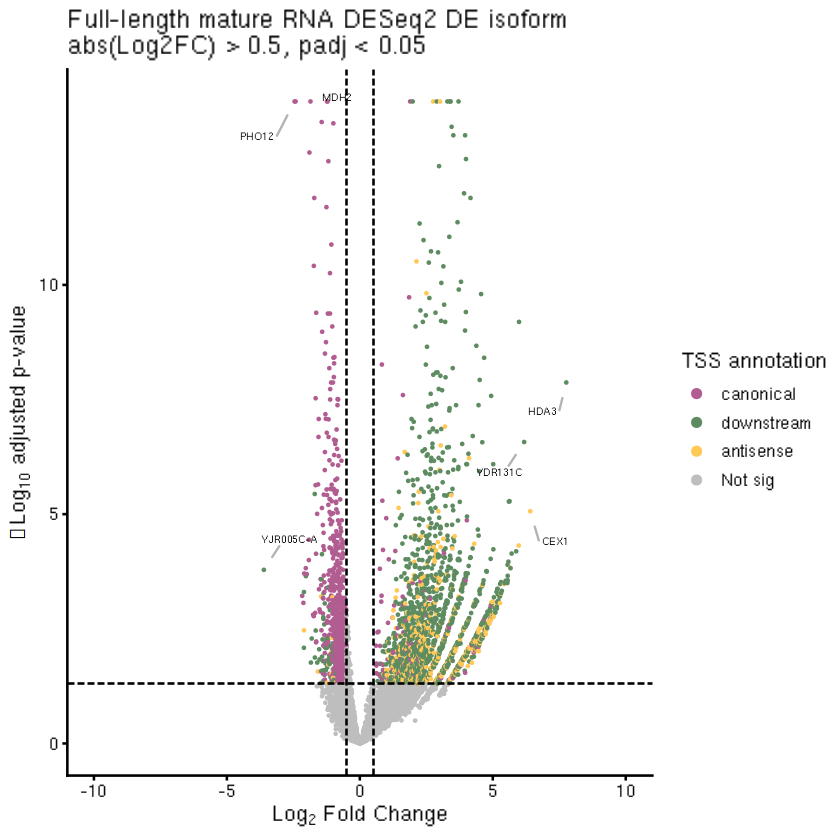

In [77]:
p <- de_df %>%
    ggplot(aes(x = log2FoldChange, y = -log10(padj), label = annotation)) +
    geom_point(aes(color = type), size = 0.2) +
    geom_text_repel(box.padding = 1, point.padding = 1, max.overlaps =10, size = 2, segment.color = "grey70") +
    labs(x = expression(Log[2] * " Fold Change"), y = expression(-Log[10] * " adjusted p-value"), 
       title = "Full-length mature RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", color = "TSS annotation")  +
    geom_hline(yintercept = -log10(0.05), color = 'black', linetype = "longdash") +
    geom_vline(xintercept = 0.5, color = 'black', linetype = "longdash") +
    geom_vline(xintercept = -0.5, color = 'black', linetype = "longdash") +
    scale_color_manual(values = mcolors) +
    guides(color = guide_legend(override.aes = list(size = 2))) +
    xlim(-10,10)
p
ggsave('../figures/Figure1C_mature_rna_isoform_DE_volcano.pdf', width = 5, height = 3)

## Figure 2D

In [78]:
df2<- read.table(file = '../data/7_mature_rna_DE_fraction_by_expr.tsv', sep = '\t', header = T)

In [79]:
iso_levels <- df2 %>%
    filter(labels != "Not sig", class == "low") %>% 
    select(feature_id, labels, p) %>% 
    pivot_wider(names_from = labels, values_from = p) %>% 
    mutate(delta = `Up in MUT` - `Down in MUT`) %>% arrange(-delta) %>% 
    pull(feature_id)

In [80]:
p2<- df2 %>%
    mutate(feature_id = factor(feature_id, levels = iso_levels),
           labels = factor(labels, levels = c("Down in MUT", "Up in MUT", "Not sig")),
           class = factor(class, levels = c("low", "medium", "high"))) %>% 
    filter(labels != "Not sig") %>% 
    ggplot(aes(x = labels, y = p, fill = feature_id)) +
    geom_bar(stat='identity', position = "stack", width=0.7) +
    scale_fill_manual(values = mcolors) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(x = "", y = expression(-Log[10] * " adjusted p-value"), 
         title = "Full-length mature long-read RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", fill = "TSS annotation") +
    facet_wrap(vars(class), ncol = 3) 

ggsave("../figures/Figure2D_mature_rna_percentage_of_isoform_by_expr.pdf", p2, width = 6, height = 6)

## Figure 2E

In [81]:
df_joint<- read.table(file = "../data/7_mature_rna_joint_isoform_DE_vs_gene_de_by_expr.tsv", sep = "\t", header = T)

pdf 
  2

pdf 
  2

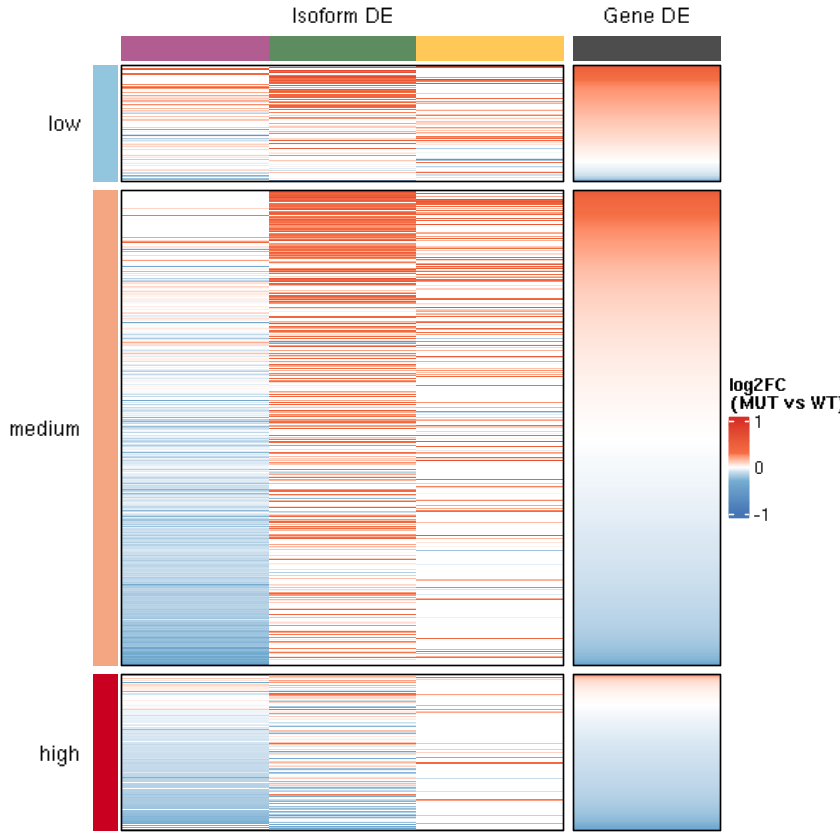

In [82]:
mat_df <- df_joint %>%
  mutate(
    class = factor(class, levels = c("low", "medium", "high"))
  ) %>%
  arrange(class) %>%
  select(gene_id, class, lfc_canonical, lfc_downstream, lfc_antisense, lfc_gene_de)

mat <- mat_df %>%
  select(lfc_canonical, lfc_downstream, lfc_antisense, lfc_gene_de) %>%
  mutate(across(everything(), ~ replace_na(., 0))) %>%
  as.matrix()

rownames(mat) <- mat_df$gene_id
colnames(mat) <- c("Canonical", "Downstream", "Antisense", "Total")

row_order_idx <- mat_df %>%
  mutate(row_idx = row_number()) %>%
  arrange(class, desc(lfc_gene_de)) %>%
  pull(row_idx)

mat    <- mat[row_order_idx, ]
mat_df <- mat_df[row_order_idx, ]

pos_max <- max(mat[mat > 0], na.rm = TRUE)
neg_min <- min(mat[mat < 0], na.rm = TRUE)

mat_scaled <- mat
mat_scaled[mat > 0] <- mat[mat > 0] / pos_max
mat_scaled[mat < 0] <- mat[mat < 0] / abs(neg_min)

lfc_cap <- 1
dir_col <- colorRamp2(
  c(-lfc_cap, -0.3, 0, 0.3, lfc_cap),
  c("#4575b4", "#74add1", "white", "#f46d43", "#d73027")
)

class_colors <- c(low = "#92c5de", medium = "#f4a582", high = "#ca0020")

mcolors <- c("#B25D91FF", "#5E8C61FF", "#FFC857FF")
names(mcolors) <- c("canonical", "downstream", "antisense")

iso_colors <- c(
  "Canonical"  = mcolors[["canonical"]],
  "Downstream" = mcolors[["downstream"]],
  "Antisense"  = mcolors[["antisense"]],
  "Total"      = "grey30"
)

# ── Row = genes, Column = isoform types ──────────────────────────────────────
row_split <- mat_df$class

col_split <- factor(
  c("Isoform DE", "Isoform DE", "Isoform DE", "Gene DE"),
  levels = c("Isoform DE", "Gene DE")
)

iso_types <- factor(colnames(mat_scaled), levels = c("Canonical", "Downstream", "Antisense", "Total"))

# Left annotation: expression class
row_ha <- rowAnnotation(
  Class = mat_df$class,
  col   = list(Class = class_colors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

# Top annotation: isoform type color bar
col_ha <- HeatmapAnnotation(
  Isoform = iso_types,
  col     = list(Isoform = iso_colors),
  show_annotation_name = FALSE,
  show_legend = FALSE
)

ht <- Heatmap(
  mat_scaled,
  name                = "log2FC",
  col                 = dir_col,
  row_split           = row_split,
  column_split        = col_split,
  cluster_rows        = FALSE,
  cluster_row_slices  = FALSE,
  cluster_columns     = FALSE,
  show_row_names      = FALSE,
  show_column_names   = FALSE,
  show_heatmap_legend = FALSE,
  row_gap             = unit(2, "mm"),
  column_gap          = unit(2, "mm"),
  row_title_rot       = 0,
  row_title_gp        = gpar(fontsize = 12),
  column_title_rot    = 0,
  column_title_gp     = gpar(fontsize = 12),
  border              = TRUE,
  rect_gp             = gpar(col = "white", lwd = 0),
  left_annotation     = row_ha,
  top_annotation      = col_ha
)

lgd_class <- Legend(
  title     = "Class",
  labels    = names(class_colors),
  legend_gp = gpar(fill = class_colors)
)
lgd_lfc <- Legend(
  title     = "log2FC\n(MUT vs WT)",
  col_fun   = dir_col,
  at        = c(-lfc_cap, 0, lfc_cap),
  labels    = c(round(-lfc_cap, 1), "0", round(lfc_cap, 1)),
  direction = "vertical"
)
lgd_iso <- Legend(
  title     = "Isoform",
  labels    = names(iso_colors),
  legend_gp = gpar(fill = iso_colors)
)

pdf("../figures/Figure2E_mature_rna_isoform_expression_DE_vs_gene_expression_DE.pdf", width = 4, height = 4)
draw(ht,
     annotation_legend_list = list(lgd_lfc),
     heatmap_legend_side = "right")
dev.off()

png("../figures/Figure2E_mature_rna_isoform_expression_DE_vs_gene_expression_DE.png", res = 300, units = "in", width = 4, height = 4)
draw(ht,
     annotation_legend_list = list(lgd_lfc),
     heatmap_legend_side = "right")
dev.off()

draw(ht,
     annotation_legend_list = list(lgd_lfc),
     heatmap_legend_side = "right")

## Figure2F

In [83]:
df<- read.table(file = "../data/7_mature_rna_joint_isoform_DE_count_by_expr.tsv", sep = "\t", header = T)

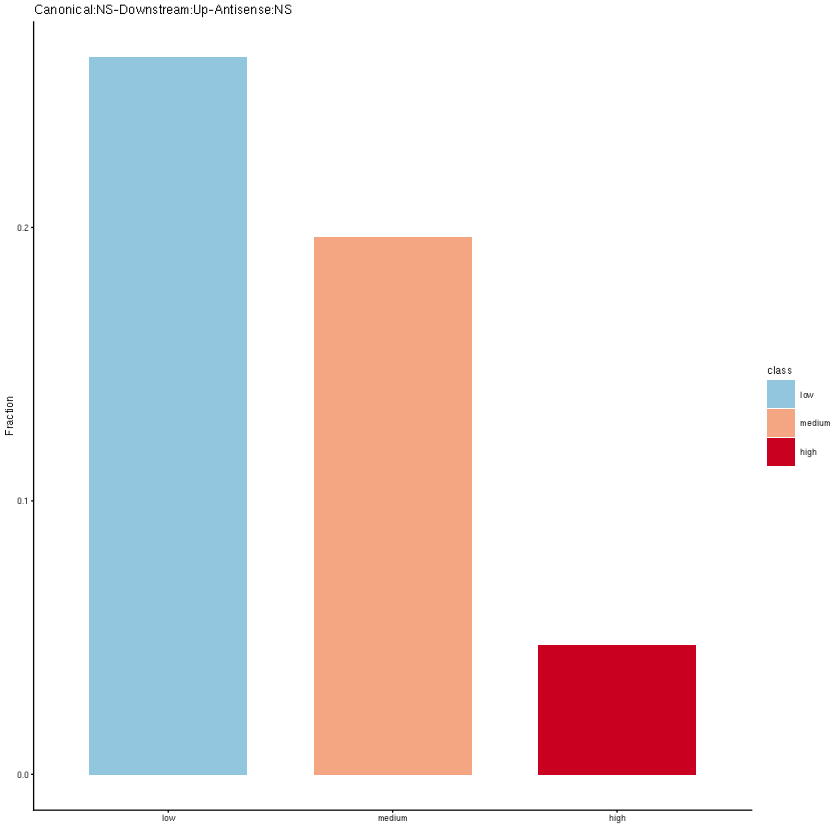

In [84]:
title = 'Canonical:NS-Downstream:Up-Antisense:NS'
df %>% filter(combo == "C:NS | D:Up | A:NS") %>% 
    mutate(class  = factor(class, levels = c("low", "medium", "high"))) %>% 
    ggplot(aes(x = class, y = frac, fill = class)) +
        geom_bar(stat = "identity", position = "stack", width = 0.7) +
        scale_fill_manual(values = class_colors) +
        theme(legend.position = "none") +
        labs(x = "", y = "Fraction", title = title) +
    theme_classic(base_size = 6)
ggsave('../figures/Figure2F_ Canonical_NS_Downstream_Up_Antisense_NS.pdf', width = 3, height = 2.5)

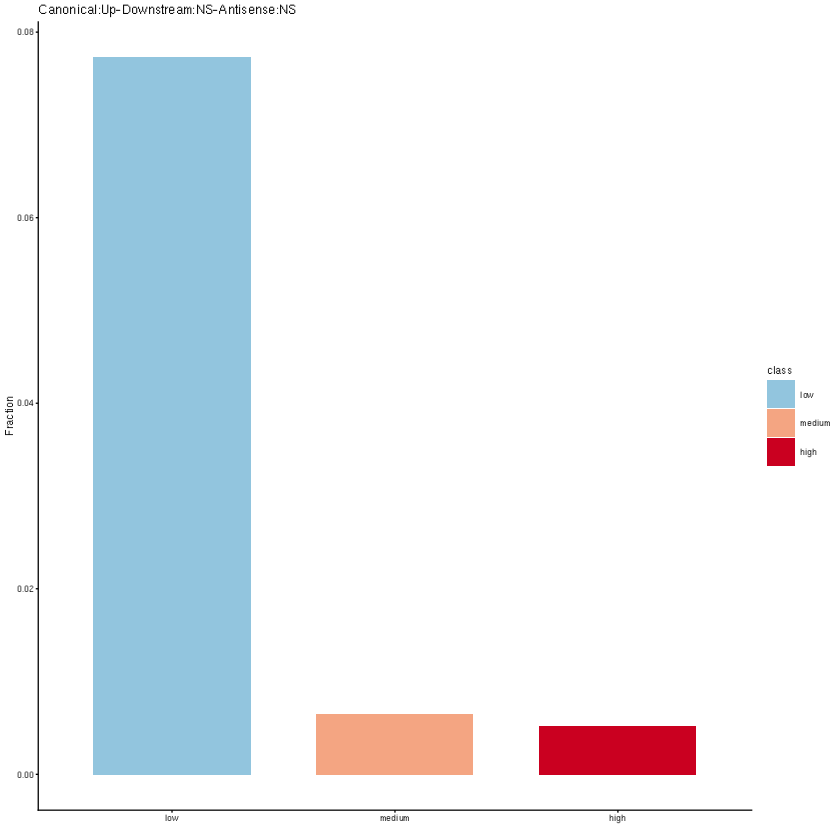

In [85]:
title = 'Canonical:Up-Downstream:NS-Antisense:NS'
df %>% filter(combo == "C:Up | D:NS | A:NS") %>% 
    mutate(class  = factor(class, levels = c("low", "medium", "high"))) %>% 
    ggplot(aes(x = class, y = frac, fill = class)) +
        geom_bar(stat = "identity", position = "stack", width = 0.7) +
        scale_fill_manual(values = class_colors) +
        theme(legend.position = "none") +
        labs(x = "", y = "Fraction", title = title) +
    theme_classic(base_size = 6)
ggsave('../figures/Figure2F_ Canonical_Up_Downstream_NS_Antisense_NS.pdf', width = 3, height = 2.5)

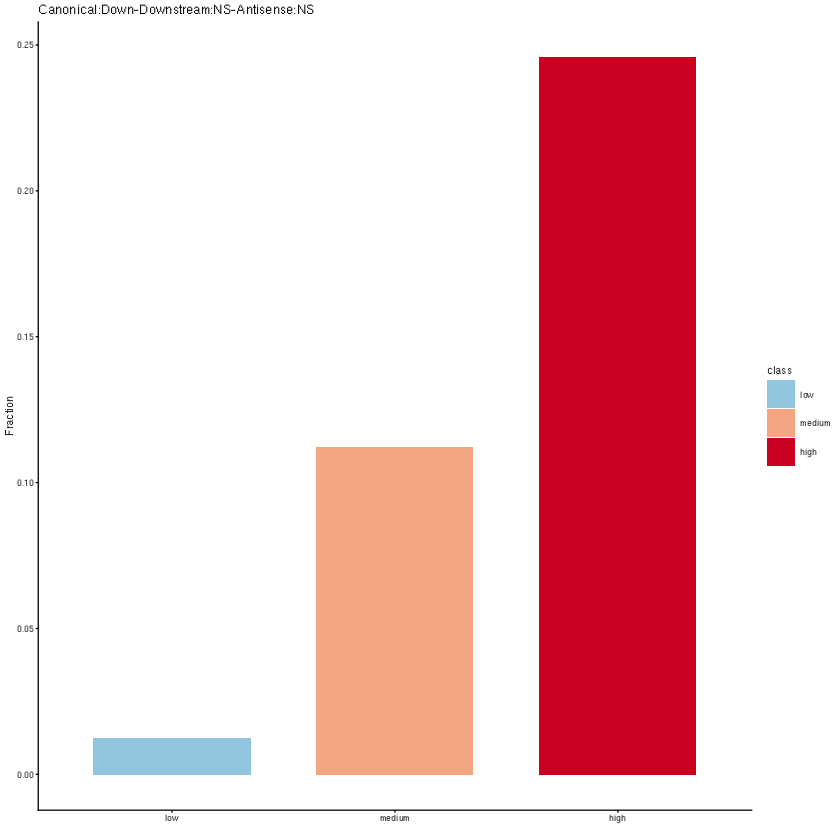

In [86]:
title = 'Canonical:Down-Downstream:NS-Antisense:NS'
df %>% filter(combo == "C:Down | D:NS | A:NS") %>% 
    mutate(class  = factor(class, levels = c("low", "medium", "high"))) %>% 
    ggplot(aes(x = class, y = frac, fill = class)) +
        geom_bar(stat = "identity", position = "stack", width = 0.7) +
        scale_fill_manual(values = class_colors) +
        theme(legend.position = "none") +
        labs(x = "", y = "Fraction", title = title) +
    theme_classic(base_size = 6)
ggsave('../figures/Figure2F_ Canonical_Down_Downstream_NS_Antisense_NS.pdf', width = 3, height = 2.5)

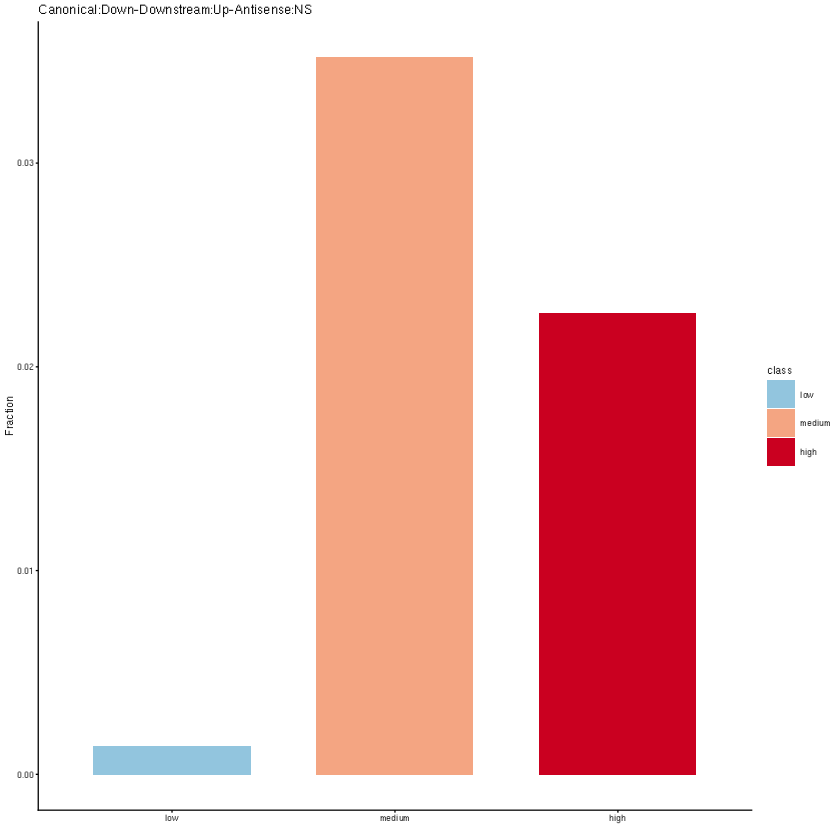

In [87]:
title = 'Canonical:Down-Downstream:Up-Antisense:NS'
df %>% filter(combo == "C:Down | D:Up | A:NS") %>% 
    mutate(class  = factor(class, levels = c("low", "medium", "high"))) %>% 
    ggplot(aes(x = class, y = frac, fill = class)) +
        geom_bar(stat = "identity", position = "stack", width = 0.7) +
        scale_fill_manual(values = class_colors) +
        theme(legend.position = "none") +
        labs(x = "", y = "Fraction", title = title) +
    theme_classic(base_size = 6)
ggsave('../figures/Figure2F_ Canonical_Down_Downstream_Up_Antisense_NS.pdf', width = 3, height = 2.5)